In [1]:
import os
import json

import time
import random
import numpy as np
from PIL import Image
import cv2
import matplotlib.pyplot as plt
import kagglehub
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, Dataset, DataLoader, random_split
import torchvision.transforms as T
import torch.nn.functional as F
import pickle
import gzip
from google.colab import drive
drive.mount('/content/drive')
base_dir = '/content/drive/My Drive/'
# base_dir = ''

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# 1. Original IPN Hand dataset (videos)
ipn_path = kagglehub.dataset_download("soumicksarker/ipn-hand-dataset")
print("IPN dataset:", ipn_path)

# --- Paths ---
videos_dir = os.path.join(ipn_path, "videos/videos")  # raw video files

annotations_path = os.path.join(ipn_path, "annotations/annotations")

def read_annotations(path):
    with open(path, 'r') as f:
        annots = []
        for idx, line in enumerate(f):
            if idx > 0:
                # Parse annotations and convert frame info into ints
                info = line.split(',')
                for i in range(2, len(info)):
                    info[i] = int(info[i])
                annots.append(info)
    return annots

annots = read_annotations(os.path.join(annotations_path, "Annot_List.txt"))


Using Colab cache for faster access to the 'ipn-hand-dataset' dataset.
IPN dataset: /kaggle/input/ipn-hand-dataset


In [3]:
# Use the same UNet() model from UNetScratchModel to extract segmentations

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[64,128,256,512]):
        super(UNet, self).__init__()
        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()

        # Encoder
        for f in features:
            self.downs.append(self.conv_block(in_channels, f))
            in_channels = f

        # Bottleneck
        self.bottleneck = self.conv_block(features[-1], features[-1]*2)

        # Decoder
        for f in reversed(features):
            self.ups.append(nn.ConvTranspose2d(f*2, f, kernel_size=2, stride=2))
            self.ups.append(self.conv_block(f*2, f))

        # Final output
        self.final = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = F.max_pool2d(x, 2)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip = skip_connections[idx//2]
            if x.shape != skip.shape:
                x = F.interpolate(x, size=skip.shape[2:])
            x = torch.cat([skip, x], dim=1)
            x = self.ups[idx+1](x)

        return torch.sigmoid(self.final(x))

    def conv_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )


In [4]:
class IPNDataPreProcessor:
    def __init__(self, annots, vid_path, transform = None):
        self.videos_path = vid_path

        self.annots = annots
        self.n = len(annots)
        self.videos_path = vid_path
        self.annots = annots
        self.transform = transform

        # Constants
        self.min_frames = 5
        self.num_frames = 80

        self.TARGET_SIZE = (256, 256)


    def __len__(self):
        return len(self.annots)

    def get_frames(self, video_name, start_frame, end_frame):
        video_path = os.path.join(self.videos_path, video_name + ".avi")

        cap = cv2.VideoCapture(video_path)
        cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
        if not cap.isOpened():
            raise FileNotFoundError(f"Video file not found: {video_path}")

        frames = []

        for frame_i in range(start_frame, end_frame):

            ret, frame = cap.read()
            if not ret:
                break

            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, self.TARGET_SIZE)
            frames.append(frame)

        cap.release()

        return frames

    def __getitem__(self, idx):
        info = self.annots[idx]
        video_name, label, label_id, start_frame, end_frame, num_frames = info
        frames = self.get_frames(video_name, start_frame, end_frame)

        # # Pad/truncate to fixed length
        frames = self.pad_sequence(frames, self.num_frames)

        # Convert to tensors
        frames = torch.tensor(np.stack(frames)).permute(0,3,1,2).float() / 255.0

        return frames, label_id

    def pad_sequence(self, seq, target_len):
        seq_len = len(seq)
        if seq_len >= target_len:
            return seq[:target_len]

        pad_item = np.zeros_like(seq[0])
        padding = [pad_item.copy() for _ in range(target_len - seq_len)]
        return seq + padding


In [5]:
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

save_path = os.path.join(base_dir, "models", "hand_seg_model.pth")
save_path_seg = os.path.join(base_dir, "videos", "segmented_vids_200.pt")
out_path = os.path.join(base_dir, "videos")
device = "cuda" if torch.cuda.is_available() else "cpu"

if not os.path.exists(save_path):
    raise FileNotFoundError(
        f"❌ The file {save_path} does NOT exist.\n"
        f"Set TRAIN_NEW_MODEL = True to train a new model first."
    )

# -------------------------
# Transform
# -------------------------
transform = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor()
])

# -------------------------
# Dataset
# -------------------------
dataset = IPNDataPreProcessor(
    annots,
    vid_path=videos_dir,
    transform=transform
)

# -------------------------
# Gesture labels
# -------------------------
ID_TO_GESTURE = {
    0: "Non-gesture",
    1: "Pointing with one finger",
    2: "Pointing with two fingers",
    3: "Click with one finger",
    4: "Click with two fingers",
    5: "Throw up",
    6: "Throw down",
    7: "Throw left",
    8: "Throw right",
    9: "Open twice",
    10: "Double click with one finger",
    11: "Double click with two fingers",
    12: "Zoom in",
    13: "Zoom out",
}

# -------------------------
# Load or extract masks
# -------------------------
all_masks = []
all_labels = []

# If you want to recalculate segmentation masks, set this to True
RECALCULATE_MASKS = False

if RECALCULATE_MASKS:
    print(f"Dataset length: {len(dataset)}")

    # Load trained UNet
    unet_model = UNet().to(device)
    unet_model.load_state_dict(torch.load(save_path, map_location=device))
    unet_model.eval()

    loader = DataLoader(dataset, batch_size=1, shuffle=False)

    for seq_idx, (imgs, labels) in enumerate(loader):
        if seq_idx > 500:  # limit to first 500 videos
            break

        imgs = imgs.squeeze(0)  # remove batch dimension
        num_frames = imgs.shape[0]

        frames = []
        height, width = imgs.shape[2], imgs.shape[3]  # original frame size

        for i in range(num_frames):
            frame = imgs[i].unsqueeze(0).to(device)
            with torch.no_grad():
                pred = unet_model(frame)

            # Convert mask to 0-255 uint8 and resize
            mask_np = (pred.squeeze().cpu().numpy() * 255).astype('uint8')
            mask_resized = cv2.resize(mask_np, (width, height))
            mask_tensor = torch.from_numpy(mask_resized).unsqueeze(0)

            frames.append(mask_tensor)

        all_masks.append(torch.stack(frames))
        all_labels.append(labels)

        print(f"Processed segmented video {seq_idx}")

    # Save all masks and labels to .pt
    torch.save({
        "masks": all_masks,
        "labels": all_labels
    }, save_path_seg)

else:
    if not os.path.exists(save_path_seg):
        raise FileNotFoundError(
            f"❌ The file {save_path_seg} does NOT exist.\n"
            f"Set RECALCULATE_MASKS = True to generate masks first."
        )

    # Load on CPU first to avoid CUDA errors
    data = torch.load(save_path_seg, map_location='cpu')  # Changed from device to 'cpu'
    all_masks = data["masks"]
    all_labels = data["labels"]

print("✅ Loaded data:")
print(f"Number of videos: {len(all_masks)}")
print(f"Number of labels: {len(all_labels)}")

# Fix labels: convert from 1-14 to 0-13
for i in range(len(all_labels)):
    if torch.is_tensor(all_labels[i]):
        all_labels[i] = all_labels[i] - 1
    else:
        all_labels[i] = all_labels[i] - 1


# Clear CUDA cache to reset any error state
torch.cuda.empty_cache()
if torch.cuda.is_available():
    torch.cuda.synchronize()

✅ Loaded data:
Number of videos: 201
Number of labels: 201
⚠️ Converting labels from 1-14 to 0-13...
✅ Labels converted. Range now: 0 to 13


Number of videos: 201
Number of labels: 201

Label statistics:
Min label: 1
Max label: 14
Unique labels: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Label counts: (array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14]), array([36, 40, 39,  8,  8,  8,  8,  7,  8,  8,  7,  8,  8,  8]))

Mask information:
First mask shape: torch.Size([80, 1, 256, 256])
First mask dtype: torch.uint8
First mask min/max: 0.00/241.00
Input feature size: 240
Training samples: 154, Validation samples: 39
Epoch [1/100] Train Loss: 2.6150, Train Acc: 0.1818 | Val Loss: 2.6130, Val Acc: 0.2051
Epoch [2/100] Train Loss: 2.3097, Train Acc: 0.2792 | Val Loss: 2.1014, Val Acc: 0.2564
Epoch [3/100] Train Loss: 2.2901, Train Acc: 0.2532 | Val Loss: 1.9790, Val Acc: 0.2821
Epoch [4/100] Train Loss: 2.1572, Train Acc: 0.2792 | Val Loss: 1.9997, Val Acc: 0.3077
Epoch [5/100] Train Loss: 2.1325, Train Acc: 0.3182 | Val Loss: 1.9970, Val Acc: 0.2308
Epoch [6/100] Train Loss: 2.1686, Train Acc: 0.2792 | Val Loss:

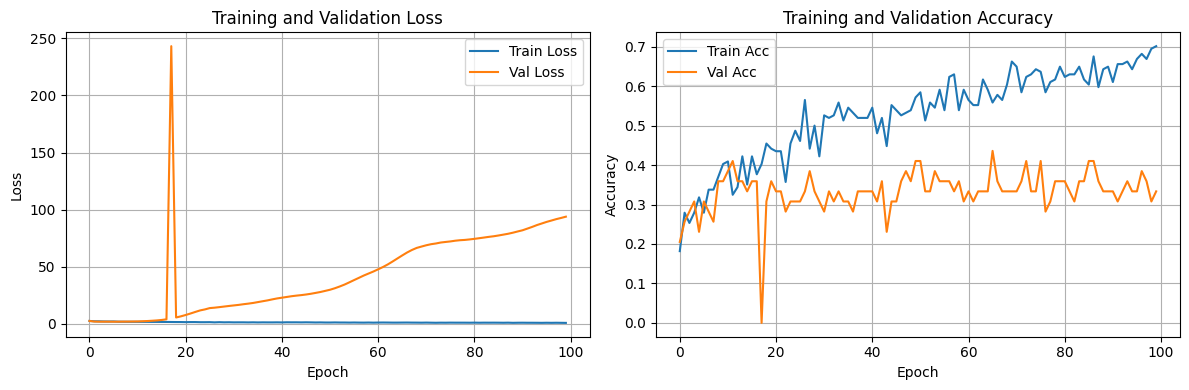

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# -------------------------
# MLP Model Definition
# -------------------------
class GestureMLP(nn.Module):
    def __init__(self, input_size, hidden_sizes=[256, 128], num_classes=14, dropout=0.5):
        super(GestureMLP, self).__init__()

        layers = []
        prev_size = input_size

        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(nn.Dropout(dropout))
            prev_size = hidden_size

        layers.append(nn.Linear(prev_size, num_classes))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

# -------------------------
# Dataset Wrapper
# -------------------------
class MaskDataset(Dataset):
    def __init__(self, masks, labels, aggregate='mean'):
        self.masks = masks
        self.labels = labels
        self.aggregate = aggregate

    def __len__(self):
        return len(self.masks)

    def __getitem__(self, idx):
        mask = self.masks[idx]  # Shape: [num_frames, 1, H, W]
        label = self.labels[idx]

        # Flatten spatial dimensions and aggregate over time
        mask = mask.float()  # Ensure float type

        if self.aggregate == 'mean':
            # Average pool over frames and spatial dimensions
            features = mask.mean(dim=[0, 2, 3])  # [1]
        elif self.aggregate == 'flatten':
            # Use all frame statistics
            features = torch.stack([
                mask.mean(),
                mask.std(),
                mask.max(),
                mask.min()
            ])
        elif self.aggregate == 'temporal':
            # Extract temporal features per frame
            num_frames = mask.shape[0]
            frame_features = []
            for i in range(num_frames):
                frame = mask[i]
                frame_features.extend([
                    frame.mean().item(),
                    frame.std().item(),
                    frame.max().item()
                ])
            features = torch.tensor(frame_features)

        return features, label.item() if torch.is_tensor(label) else label

# -------------------------
# Training Function
# -------------------------
def train_mlp(model, train_loader, val_loader, criterion, optimizer, num_epochs=50, device='cuda'):
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    best_val_acc = 0.0
    best_model_state = None

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        train_preds = []
        train_labels = []

        for features, labels in train_loader:
            features = features.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(features)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            train_preds.extend(preds.cpu().numpy())
            train_labels.extend(labels.cpu().numpy())

        train_loss /= len(train_loader)
        train_acc = accuracy_score(train_labels, train_preds)
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_preds = []
        val_labels = []

        with torch.no_grad():
            for features, labels in val_loader:
                features = features.to(device)
                labels = labels.to(device)

                outputs = model(features)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        val_loss /= len(val_loader)
        val_acc = accuracy_score(val_labels, val_preds)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()

        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    return best_model_state, train_losses, val_losses, train_accs, val_accs

# -------------------------
# Data Validation and Debugging
# -------------------------

data = torch.load(save_path_seg, map_location='cpu')
all_masks = data["masks"]
all_labels = data["labels"]

print(f"Number of videos: {len(all_masks)}")
print(f"Number of labels: {len(all_labels)}")

# Check label values
all_label_values = []
for label in all_labels:
    if torch.is_tensor(label):
        all_label_values.append(label.item())
    else:
        all_label_values.append(label)

print(f"\nLabel statistics:")
print(f"Min label: {min(all_label_values)}")
print(f"Max label: {max(all_label_values)}")
print(f"Unique labels: {sorted(set(all_label_values))}")
print(f"Label counts: {np.unique(all_label_values, return_counts=True)}")

# Check for invalid labels (should be 0-13 for 14 classes)
invalid_labels = [l for l in all_label_values if l < 0 or l > 13]
if invalid_labels:

    valid_indices = [i for i, l in enumerate(all_label_values) if 0 <= l <= 13]
    all_masks = [all_masks[i] for i in valid_indices]
    all_labels = [all_labels[i] for i in valid_indices]
    all_label_values = [all_label_values[i] for i in valid_indices]


# Check mask shapes
print(f"\nMask information:")
print(f"First mask shape: {all_masks[0].shape}")
print(f"First mask dtype: {all_masks[0].dtype}")
print(f"First mask min/max: {all_masks[0].min():.2f}/{all_masks[0].max():.2f}")

# -------------------------
# Main Training Script
# -------------------------

# Create dataset with temporal features
mask_dataset = MaskDataset(all_masks, all_labels, aggregate='temporal')

# Split into train/val
train_size = int(0.8 * len(mask_dataset))
val_size = len(mask_dataset) - train_size
train_dataset, val_dataset = random_split(mask_dataset, [train_size, val_size])

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Get input size from first sample
sample_features, _ = mask_dataset[0]
input_size = sample_features.shape[0]

print(f"Input feature size: {input_size}")
print(f"Training samples: {train_size}, Validation samples: {val_size}")

# Initialize model
model = GestureMLP(input_size=input_size, hidden_sizes=[64], num_classes=14, dropout=0.5).to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

best_state, train_losses, val_losses, train_accs, val_accs = train_mlp(
    model, train_loader, val_loader, criterion, optimizer,
    num_epochs=100, device=device
)

model.load_state_dict(best_state)

mlp_save_path = os.path.join(base_dir, "models", "gesture_mlp.pth")
torch.save(best_state, mlp_save_path)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses, label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(train_accs, label='Train Acc')
ax2.plot(val_accs, label='Val Acc')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# Final evaluation
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for features, labels in val_loader:
        features = features.to(device)
        outputs = model(features)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())